# Inspect available evolutionary models

Let's explore relevant information about the evolutionary models available via SEDA.

In [1]:
import seda
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.constants import R_jup, R_sun, M_sun, M_jup



    SEDA v0.1.dev1351 package imported


## Available models

In [2]:
seda.models.EvolutionaryModels().available_models

['Sonora_Diamondback', 'BHAC2015', 'ATMO2020', 'Sonora_Bobcat']

## Evolutionary model grids overview

Read relevant information from models of interest.

Let's select the 'Sonora_Diamondback' grid:

In [3]:
model = 'Sonora_Diamondback'

Read some parameters:

In [4]:
print(seda.models.EvolutionaryModels(model).ref) # reference
print(seda.models.EvolutionaryModels(model).ADS) # link to paper
print(seda.models.EvolutionaryModels(model).download) # link to download the models
print(seda.models.EvolutionaryModels(model).columns) # columns in each evolutionary table
print(seda.models.EvolutionaryModels(model).units) # units of each column

Morley et al (2024)
https://ui.adsabs.harvard.edu/abs/2024ApJ...975...59M/abstract
https://zenodo.org/records/12735103
['mass', 'age', 'logL', 'Teff', 'logg', 'radius']
{'mass': 'M_sun', 'age': 'Gyr', 'logL': 'log10(L/Lsun)', 'Teff': 'K', 'logg': 'cgs dex', 'radius': 'R_jup'}


Look at other available parameters:

In [5]:
help(seda.models.EvolutionaryModels)

Help on class EvolutionaryModels in module seda.models:

class EvolutionaryModels(builtins.object)
 |  EvolutionaryModels(model=None)
 |  
 |  Description:
 |  ------------
 |          See available evolutionary models and get basic parameters from a desired grid.
 |  
 |  Parameters:
 |  -----------
 |  - model : str, optional
 |          Evolutionary models. If provided, the model metadata from its ``config.json``
 |          (e.g. ``ref``, ``bibcode``, ``ADS``, ``download``, ``columns``, ``units``) is
 |          assigned as attributes. If omitted, only ``available_models`` is set.
 |  
 |  Attributes:
 |  -----------
 |  - available_models (list) : Evolutionary models available on SEDA.
 |  - available_tables (list) : Bundled table basenames for ``model`` (if provided).
 |  - params (dict) : Per-table ``[min, max]`` for each grid column returned by the plugin (if provided).
 |  
 |  Example:
 |  --------
 |  >>> import seda
 |  >>>
 |  >>> # see available evolutionary models
 |  >>

Read more about the [available evolutionary models](https://seda.readthedocs.io/en/latest/overview.html#evolutionary-models).

Check the bundled evolutionary tables along with the coverage of their columns:

In [6]:
filename = 'hybrid-grav_f2_m-0.5_mass' # bundled table for Sonora Diamondback

print('Bundled tables:')
print(seda.models.EvolutionaryModels(model).available_tables)

grid = seda.models.read_evolutionary_model(filename=filename, model=model)

# grid['logL'] is log10(L/L_sun); convert to linear Lbol in L_sun for display
Lbol = 10.0 ** grid['logL']
R_rjup = (grid['radius'] * R_sun).to(R_jup).value

coverage = {
    'logL': [grid['logL'].min(), grid['logL'].max()],  # log10(L/L_sun)
    'Lbol': [Lbol.min(), Lbol.max()],                    # linear L_sun
    'R': [R_rjup.min(), R_rjup.max()],
}
for col in grid:
    if col in ('logL', 'radius'):
        continue
    coverage[col] = [grid[col].min(), grid[col].max()]

coverage

Bundled tables:
['hybrid-grav_f2_m+0.5_mass', 'hybrid-grav_f2_m-0.5_mass', 'hybrid-grav_f2_m0.0_mass', 'hybrid_f2_m+0.5_mass', 'hybrid_f2_m-0.5_mass', 'hybrid_f2_m0.0_mass', 'nc_m+0.5_mass', 'nc_m-0.5_mass', 'nc_m0.0_mass']


{'logL': [-7.7842, -2.779],
 'Lbol': [1.6436146363905513e-08, 0.0016634126503701698],
 'R': [7.259444413360935, 20.74683041459184],
 'mass': [0.0005, 0.08],
 'age': [0.002, 13.0],
 'Teff': [201.52, 2499.38],
 'logg': [2.741, 5.489]}

## Coverage of evolutionary grid parameters

Choose the horizontal, vertical, and color parameters before plotting. Any grid column is allowed, plus derived observables ``Lbol`` (linear L_sun) and ``R`` (radius in R_jup). You may also plot ``logL`` directly on an axis if you prefer logarithmic luminosity. The inference functions take **linear** ``Lbol`` in L_sun: ``evol_params`` uses ``Lbol`` and ``R``; ``isochrone_params`` uses ``Lbol`` and ``age``.


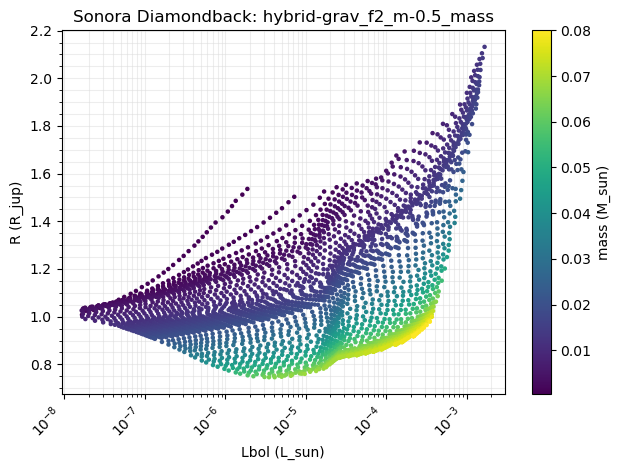

In [7]:
# Plot axes for the evolutionary grid (set before calling the plot function)
xparam = 'Lbol'
yparam = 'R'
zparam = 'mass'

fig, ax = seda.plots.plot_evolutionary_coverage(
    model=model,
    filename=filename,
    xparam=xparam,
    yparam=yparam,
    zparam=zparam,
    xlog=True, #log scale
    save=True,
)


Change ``zparam`` to explore another dimension of the same table:


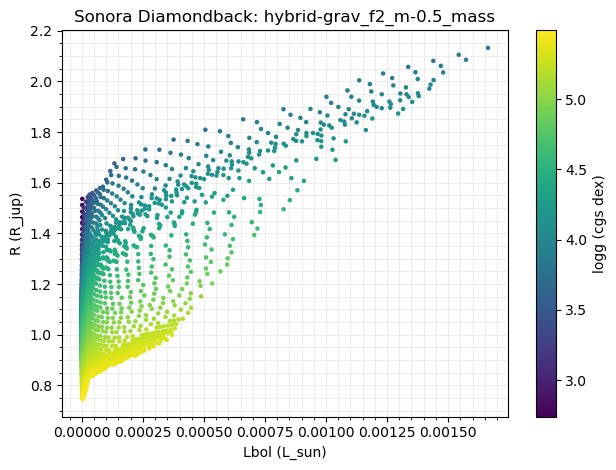

In [8]:
zparam = 'logg'

fig, ax = seda.plots.plot_evolutionary_coverage(
    model=model,
    filename=filename,
    xparam=xparam,
    yparam=yparam,
    zparam=zparam,
    xlog=False, #no log-scale
    save=True,
)


Sonora Bobcat spans a large age range (0.001–15 Gyr). Use ``zparam='age'`` to see how age maps across the grid:


['nc+0.0_co1.0_mass', 'nc+0.5_co1.0_mass', 'nc-0.5_co1.0_mass']


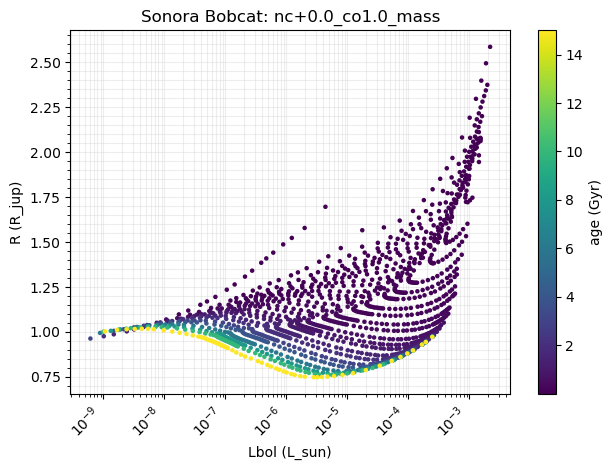

In [13]:
model = 'Sonora_Bobcat'
filename = 'nc+0.0_co1.0_mass'  # cloud-free evolution at solar metallicity

print(seda.models.EvolutionaryModels(model).available_tables)

xparam = 'Lbol'
yparam = 'R'
zparam = 'age'

fig, ax = seda.plots.plot_evolutionary_coverage(
    model=model,
    filename=filename,
    xparam=xparam,
    yparam=yparam,
    zparam=zparam,
    xlog=True,
    save=True,
)


## Infer parameters with `evol_params`

Given bolometric luminosity and radius, interpolate the evolutionary grid to recover mass, age, surface gravity, and effective temperature:


In [10]:
# Example: solar-metallicity Bobcat at the Sun-like values
Lbol, eLbol = 6.324e-5, 6.978e-6  # linear L_sun (not log10)
R, eR = 1.018, 0.059              # R_jup

out = seda.phy_params.evol_params(
    Lbol=Lbol, eLbol=eLbol, R=R, eR=eR,
    model='Sonora_Bobcat', filename='nc+0.0_co1.0_mass',
)
out['mass'], out['age'], out['logg'], out['Teff'] #tuple output on last line


27/10000 (0.3%) Monte Carlo samples fell outside the evolutionary grid and were excluded from the statistics.

Inferred fundamental parameters (Sonora Bobcat, nc+0.0_co1.0_mass):
   mass = 0.03981 (-0.008047, +0.009346) M_sun
   age = 0.5039 (-0.1943, +0.3251) Gyr
   Teff = 1597 (-64.2, +63.54) K
   logg = 4.972 (-0.1492, +0.1518) cgs dex


(0.03981159107609815, 0.503923796507323, 4.971771198815494, 1596.5649706971917)

## Infer parameters with `isochrone_params`

When radius is unknown but age is, use ``isochrone_params`` instead. The example below follows Zhang et al. (2021) GJ 570D (Table 6): the primary age is only constrained over **1.4–5.2 Gyr**, so we adopt a representative age of 3.3 Gyr with ``eage = 1.9 Gyr`` to span that range:


In [11]:
# Zhang et al. (2021) quote log10(L/L_sun); convert to linear Lbol for isochrone_params
logL = -5.54              # log10(L/L_sun)
e_logL = 0.03             # uncertainty on log10(L/L_sun)
Lbol = 10.0 ** logL       # linear bolometric luminosity (L_sun)
eLbol = Lbol * np.log(10) * e_logL

age_gyr = 3.3   # mid-point of the 1.4–5.2 Gyr primary age range
eage_gyr = 1.9  # half-width (~1.4 to 5.2 Gyr)

iso = seda.phy_params.isochrone_params(
    Lbol=Lbol, eLbol=eLbol,
    age=age_gyr, eage=eage_gyr,
    model='Sonora_Bobcat', filename='nc+0.0_co1.0_mass',
)

mass_mjup = iso['mass'] * (M_sun / M_jup).value
radius_rjup = seda.models._convert_radius_to_rjup(iso['radius'], 'Sonora_Bobcat')


mass_mjup, radius_rjup, iso['Teff'], iso['logg'] #tuple output on last line


397/10000 (4.0%) Monte Carlo samples fell outside the evolutionary grid and were excluded from the statistics.

Inferred fundamental parameters (Sonora Bobcat, nc+0.0_co1.0_mass):
   mass = 0.03655 (-0.01049, +0.008103) M_sun
   Teff = 796.3 (-34.44, +26.74) K
   logg = 5.101 (-0.2171, +0.1296) cgs dex
   radius = 0.08895 (-0.004392, +0.007478) R_sun


(38.291113844428146, 0.865628520351374, 796.3104756998271, 5.101118034364899)

Visualize the same grid in **age–Lbol** space — the two **linear** observables passed to ``isochrone_params`` (the y-axis uses a logarithmic *scale*). The error bar shows the GJ 570D constraints from above:

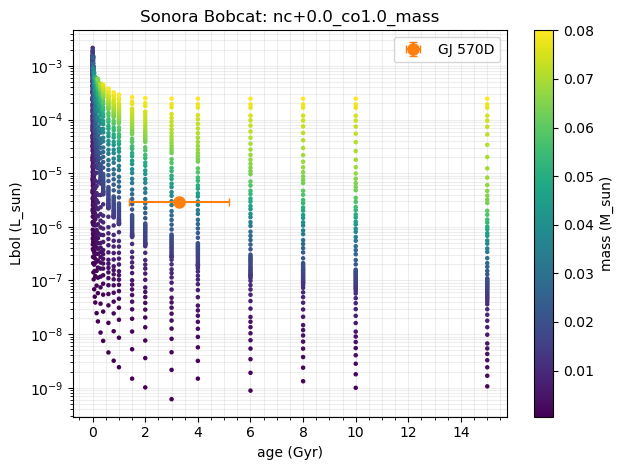

In [12]:
fig, ax = seda.plots.plot_evolutionary_coverage(
    model='Sonora_Bobcat',
    filename='nc+0.0_co1.0_mass',
    xparam='age',
    yparam='Lbol',
    zparam='mass',
    xlog=False,
    ylog=True,
)


ax.errorbar(
    age_gyr, Lbol, xerr=eage_gyr, yerr=eLbol,
    fmt='o', color='C1', ms=8, capsize=3, zorder=5, label='GJ 570D',
)
ax.legend(loc='upper right')